## Загрузка и первый взгляд на данные NBA Player Stats


Есть 2 датасета:

nba_players_2016_2026_full - статистика игроков за 2016-2026 годы

nba_teams_2016_2026_full - статистика команд за 2016-2026 годы

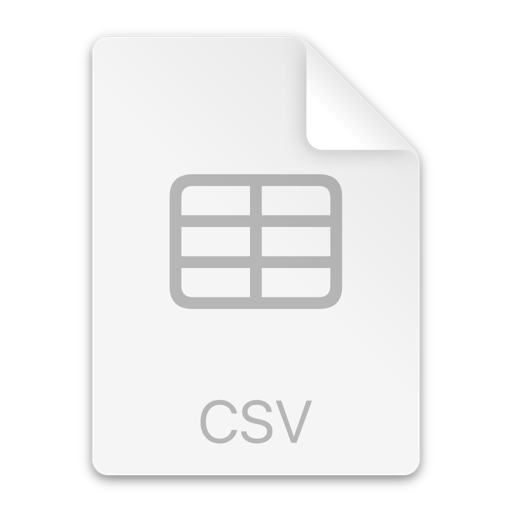

### Ключевые столбцы статистики игроков

| Группа                  | Столбцы                                     | Описание                                                                    |
|-------------------------|---------------------------------------------|-----------------------------------------------------------------------------|
| Идентификаторы          | `PLAYER_NAME`, `TEAM_ID`, `TEAM_ABBREVIATION`, `SEASON` | Имя игрока, команда, сезон, id команды                                                |
| Метаданные              | `SEASON_TYPE`, `AGE`, `GP`, `MIN`           | Тип игр (Regular Season/Playoffs), возраст, сыгранные матчи, минуты за игру |
| Бросковая эффективность | `FG_PCT`, `FG3_PCT`, `FT_PCT`      | Общий процент попаданий, 3-очковый процент, процент со штрафных             |
| Ранкинг                 | `PTS_RANK`, `AST_RANK`, `REB_RANK`  | Ранкинг очков, подборов, передач итд                                        |
| Базовая статистика      | `PTS`, `REB`, `AST`, `STL`, `BLK`, `TOV`    | Очки, подборы, передачи, перехваты, блок-шоты, потери в среднем за игру     |

### Ключевые столбцы статистики команд

| Группа             | Столбцы                                  | Описание                                                                                        |
|--------------------|------------------------------------------|-------------------------------------------------------------------------------------------------|
| Идентификаторы     | `TEAM_NAME`, `TEAM_ID`, `SEASON`         | Имя команды, id команды, сезон                                                                  |
| Метаданные         | `SEASON_TYPE`, `GP`, `W`, `L`, `MIN`     | Тип игр (Regular Season/Playoffs), возраст, сыгранные матчи, минуты за игру, победы и поражения |
| Эффективность      | `FG_PCT`, `FG_PCT`, `FG3_PCT`, `FT_PCT`  | Процент побед, общий процент попаданий, 3-очковый процент, процент со штрафных                  |
| Ранкинг            | `PTS_RANK`, `AST_RANK`, `REB_RANK`       | Ранкинг очков, подборов, передач итд                                                            |
| Базовая статистика | `PTS`, `REB`, `AST`, `STL`, `BLK`, `TOV` | Очки, подборы, передачи, перехваты, блок-шоты, потери в среднем за игру                         |

#### Загрузка данных и дополнеение их необходимыми в дальнейшем столбцами

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_players = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_players_2016_2026_full.csv')
df_teams = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_teams_2016_2026_full.csv')

df_players['TS_PCT'] = df_players['PTS'] / (2 * (df_players['FGA'] + 0.44 * df_players['FTA']))
df_players['TS_PCT'] = df_players['TS_PCT'].replace([np.inf, -np.inf], np.nan).fillna(0)

#mvp, mip, dpoy, roy, nba camp

mvp_winners = {
    "2016-17": "Russell Westbrook", "2017-18": "James Harden",
    "2018-19": "Giannis Antetokounmpo", "2019-20": "Giannis Antetokounmpo",
    "2020-21": "Nikola Jokic", "2021-22": "Nikola Jokić",
    "2022-23": "Joel Embiid", "2023-24": "Nikola Jokić",
    "2024-25": "Nikola Jokić", "2025-26": "Shai Gilgeous-Alexander"
}

dpoy_winners = {
    "2016-17": "Draymond Green", "2017-18": "Rudy Gobert",
    "2018-19": "Rudy Gobert", "2019-20": "Giannis Antetokounmpo",
    "2020-21": "Rudy Gobert", "2021-22": "Marcus Smart",
    "2022-23": "Jaren Jackson Jr.", "2023-24": "Rudy Gobert",
    "2024-25": "Evan Mobley", "2025-26": "Victor Wembanyama"
}

mip_winners = {
    "2016-17": "Giannis Antetokounmpo", "2017-18": "Victor Oladipo",
    "2018-19": "Pascal Siakam", "2019-20": "Brandon Ingram",
    "2020-21": "Julius Randle", "2021-22": "Ja Morant",
    "2022-23": "Lauri Markkanen", "2023-24": "Tyrese Maxey",
    "2024-25": "Dyson Daniels", "2025-26": "Nickeil Alexander-Walker"
}

roy_winners = {
    "2016-17": "Malcolm Brogdon", "2017-18": "Ben Simmons",
    "2018-19": "Luka Doncic", "2019-20": "Ja Morant",
    "2020-21": "LaMelo Ball", "2021-22": "Scottie Barnes",
    "2022-23": "Paolo Banchero", "2023-24": "Victor Wembanyama",
    "2024-25": "Stephon Castle"
}

champions_teams = {
    "2016-17": "Golden State Warriors", "2017-18": "Golden State Warriors",
    "2018-19": "Toronto Raptors", "2019-20": "Los Angeles Lakers",
    "2020-21": "Milwaukee Bucks", "2021-22": "Golden State Warriors",
    "2022-23": "Denver Nuggets", "2023-24": "Boston Celtics",
    "2024-25": "Oklahoma City Thunder"
}

def label_awards(df, winners_dict, col_name):
    df[col_name] = df.apply(lambda x: 1 if winners_dict.get(x['SEASON']) == x['PLAYER_NAME'] else 0, axis=1)
    return df

df_players = label_awards(df_players, mvp_winners, 'IS_MVP')
df_players = label_awards(df_players, dpoy_winners, 'IS_DPOY')
df_players = label_awards(df_players, mip_winners, 'IS_MIP')
df_players = label_awards(df_players, roy_winners, 'IS_ROY')


df_teams['IS_CHAMPION'] = df_teams.apply(
    lambda x: 1 if champions_teams.get(x['SEASON']) == x['TEAM_NAME'] else 0, axis=1
)

#usg
players = df_players.copy()
teams = df_teams.copy()

team_cols = ['TEAM_ID', 'SEASON', 'SEASON_TYPE', 'MIN', 'FGA', 'FTA', 'TOV']
teams_subset = teams[team_cols].copy()
teams_subset.columns = ['TEAM_ID', 'SEASON', 'SEASON_TYPE', 'Tm_MIN', 'Tm_FGA', 'Tm_FTA', 'Tm_TOV']

df_analysis = players.merge(teams_subset, on=['TEAM_ID', 'SEASON', 'SEASON_TYPE'], how='left')

df_players['USG_PCT'] = 100 * (
    (df_analysis['FGA'] + 0.44 * df_analysis['FTA'] + df_analysis['TOV']) * (df_analysis['Tm_MIN'])
) / (
    df_analysis['MIN'] * (df_analysis['Tm_FGA'] + 0.44 * df_analysis['Tm_FTA'] + df_analysis['Tm_TOV'])
)

df_players_reg = df_players[df_players['SEASON_TYPE'] == 'Regular Season'].copy()
df_teams_reg = df_teams[df_teams['SEASON_TYPE'] == 'Regular Season'].copy()

df_players_po = df_players[df_players['SEASON_TYPE'] == 'Playoffs'].copy()
df_teams_po = df_teams[df_teams['SEASON_TYPE'] == 'Playoffs'].copy()

print(f"Игроки: {df_players.shape[0]} строк, {df_players.shape[1]} признаков")
print(f"Команды: {df_teams.shape[0]} строк, {df_teams.shape[1]} признаков")

Игроки: 7664 строк, 75 признаков
Команды: 460 строк, 57 признаков


In [334]:
display(df_teams.head(3))

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SEASON,SEASON_TYPE,IS_CHAMPION
0,1610612737,Atlanta Hawks,82,43,39,0.524,48.5,38.1,84.4,0.451,...,7,14,22,6,3,22,19,2016-17,Regular Season,0
1,1610612738,Boston Celtics,82,53,29,0.646,48.2,38.6,85.1,0.454,...,18,23,23,21,11,7,8,2016-17,Regular Season,0
2,1610612751,Brooklyn Nets,82,20,62,0.244,48.2,37.8,85.2,0.444,...,21,18,30,25,9,12,29,2016-17,Regular Season,0


In [335]:
display(df_players.head(3))

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON,SEASON_TYPE,TS_PCT,IS_MVP,IS_DPOY,IS_MIP,IS_ROY,USG_PCT
0,1627773,AJ Hammons,AJ,1610612742,DAL,24.0,22,4,18,0.182,...,430,1,2016-17,Regular Season,0.479094,0,0,0,0,17.795372
1,201166,Aaron Brooks,Aaron,1610612754,IND,32.0,65,36,29,0.554,...,353,1,2016-17,Regular Season,0.513980,0,0,0,0,19.177787
2,203932,Aaron Gordon,Aaron,1610612753,ORL,21.0,80,29,51,0.363,...,111,1,2016-17,Regular Season,0.529696,0,0,0,0,20.075601


In [336]:
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7664 entries, 0 to 7663
Data columns (total 75 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              7664 non-null   int64  
 1   PLAYER_NAME            7664 non-null   object 
 2   NICKNAME               7664 non-null   object 
 3   TEAM_ID                7664 non-null   int64  
 4   TEAM_ABBREVIATION      7664 non-null   object 
 5   AGE                    7664 non-null   float64
 6   GP                     7664 non-null   int64  
 7   W                      7664 non-null   int64  
 8   L                      7664 non-null   int64  
 9   W_PCT                  7664 non-null   float64
 10  MIN                    7664 non-null   float64
 11  FGM                    7664 non-null   float64
 12  FGA                    7664 non-null   float64
 13  FG_PCT                 7664 non-null   float64
 14  FG3M                   7664 non-null   float64
 15  FG3A

In [353]:
df_teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TEAM_ID          460 non-null    int64  
 1   TEAM_NAME        460 non-null    object 
 2   GP               460 non-null    int64  
 3   W                460 non-null    int64  
 4   L                460 non-null    int64  
 5   W_PCT            460 non-null    float64
 6   MIN              460 non-null    float64
 7   FGM              460 non-null    float64
 8   FGA              460 non-null    float64
 9   FG_PCT           460 non-null    float64
 10  FG3M             460 non-null    float64
 11  FG3A             460 non-null    float64
 12  FG3_PCT          460 non-null    float64
 13  FTM              460 non-null    float64
 14  FTA              460 non-null    float64
 15  FT_PCT           460 non-null    float64
 16  OREB             460 non-null    float64
 17  DREB            

Почистим данные от игроков, которые сыграли меньше 5 игр и 5 минут за игру(так как достаточно часто в регулярном чемпионате возникают ситуации в концовке когда результат предрешен и на корт выходят игроки 3-го эшелона, это мусорное время, также в нба существуют 10-дневные контракты)

In [352]:
df_players_clean = df_players[(df_players['GP'] >= 5) & (df_players['MIN'] >= 5)].copy()
df_players_reg_clean = df_players_reg[(df_players_reg['GP'] >= 5) & (df_players_reg['MIN'] >= 5)].copy()

perc_cols = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'TS_PCT']
df_players_clean[perc_cols] = df_players_clean[perc_cols].fillna(0)

print(f"Игроков после фильтрации: {len(df_players_clean)}")
print(f"Игроков reg после фильтрации: {len(df_players_reg_clean)}")

Игроков после фильтрации: 6195
Игроков reg после фильтрации: 4936


## Подготовка данных по игрокам


#### Распределение данных


Гистограммы показывают усредненные значения по лиге

Так например для очков за игру большинство игроков набирает 5-10 очков но также есть суперзвезды, которые показывают запредельную результативность, но в плей-офф график смещается влево относительно регулярки

Возрастное распределение демонстрирует пик игровой формы для большинства игроков и он примерно одинаков для плей-офф и регулярки

Распределение по минутам за игру показывает ротацию
В регулярном чемпионате распределение находится в районе от 5 до 36 минут и у 40 минут за игру оно резко падает, в плей-офф же рапределение около 40 минут примерно такое же как и 20 и 30 минут

Потери в плей-офф в среднем сокращаются

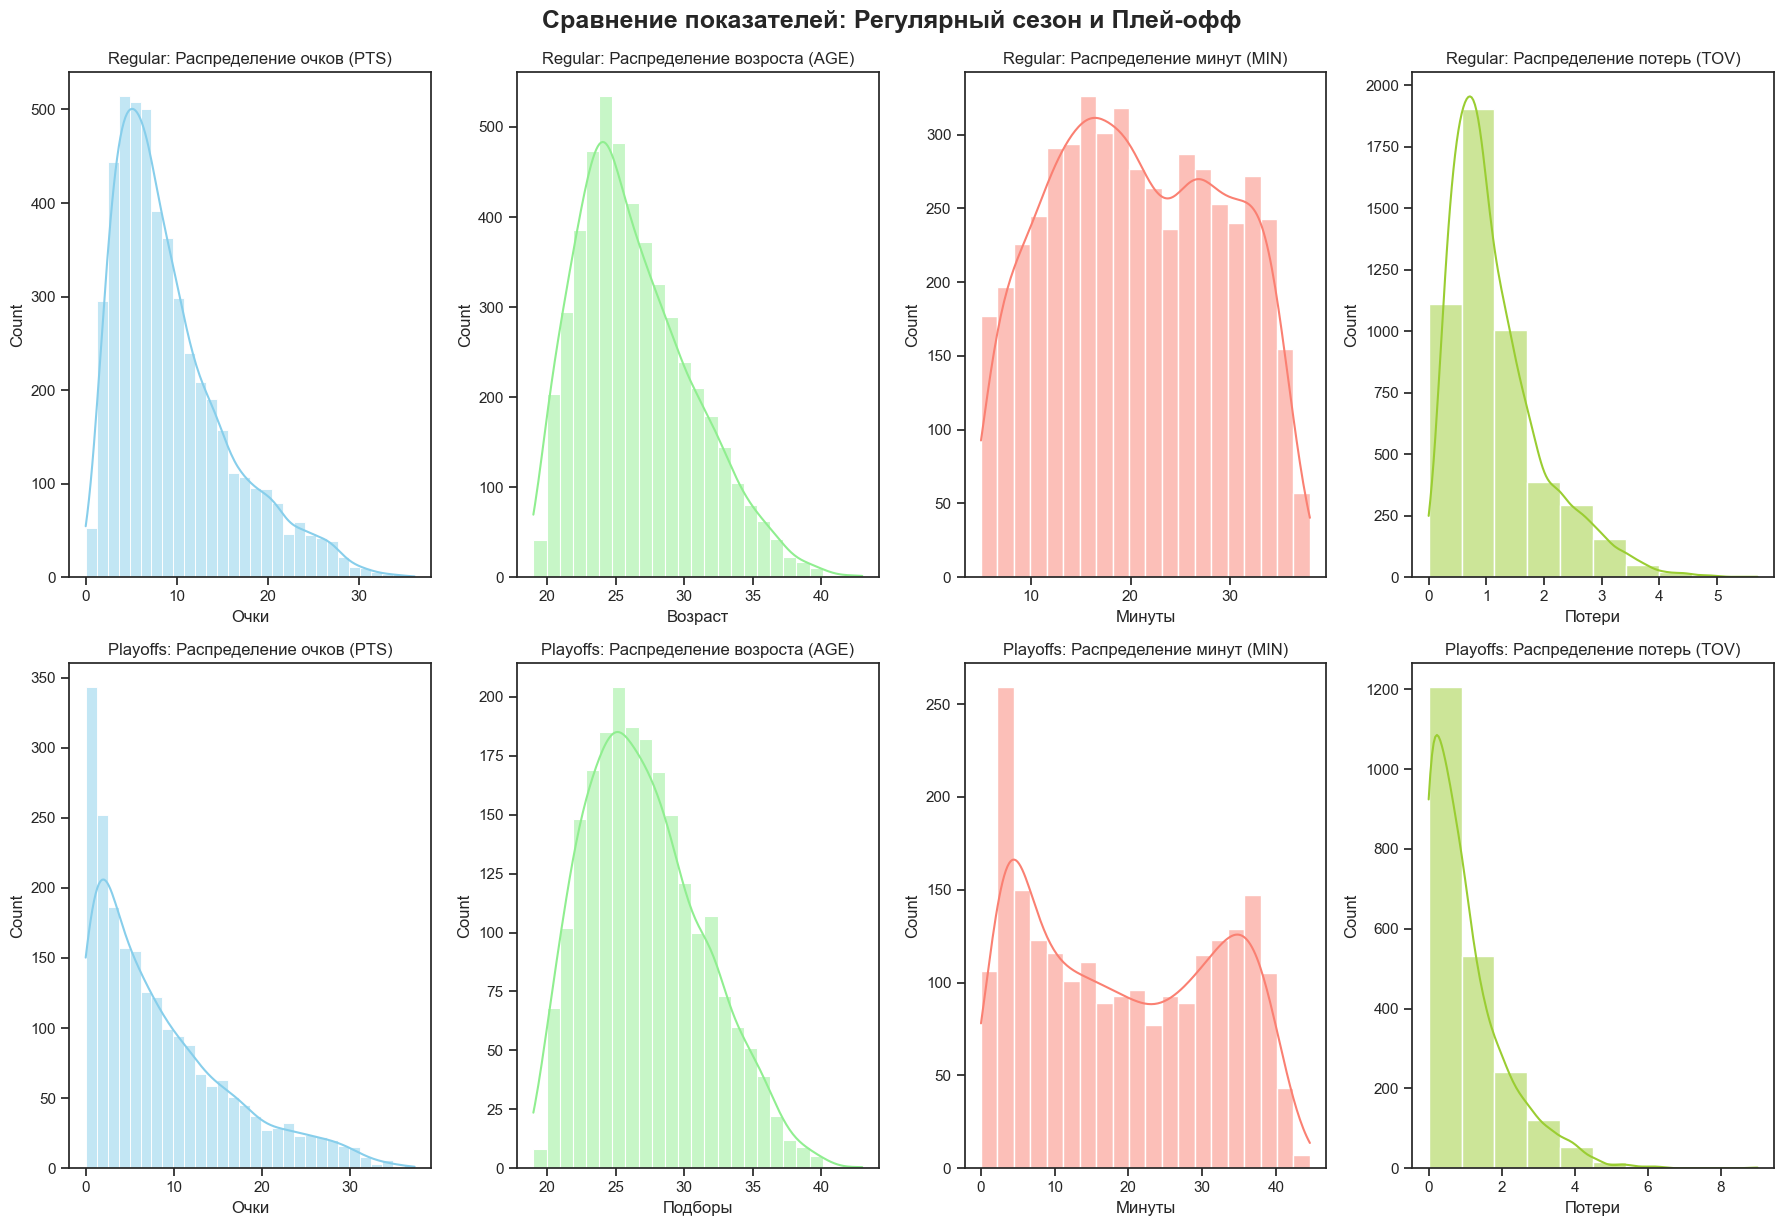

In [339]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

sns.histplot(df_players_reg_clean['PTS'], kde=True, bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Regular: Распределение очков (PTS)')
axes[0, 0].set_xlabel('Очки')

sns.histplot(df_players_reg_clean['AGE'], kde=True, bins=25, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Regular: Распределение возроста (AGE)')
axes[0, 1].set_xlabel('Возраст')

sns.histplot(df_players_reg_clean['MIN'], kde=True, bins=20, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Regular: Распределение минут (MIN)')
axes[0, 2].set_xlabel('Минуты')

sns.histplot(df_players_reg_clean['TOV'], kde=True, bins=10, ax=axes[0, 3], color='yellowgreen')
axes[0, 3].set_title('Regular: Распределение потерь (TOV)')
axes[0, 3].set_xlabel('Потери')

sns.histplot(df_players_po['PTS'], kde=True, bins=30, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Playoffs: Распределение очков (PTS)')
axes[1, 0].set_xlabel('Очки')

sns.histplot(df_players_po['AGE'], kde=True, bins=25, ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Playoffs: Распределение возроста (AGE)')
axes[1, 1].set_xlabel('Подборы')

sns.histplot(df_players_po['MIN'], kde=True, bins=20, ax=axes[1, 2], color='salmon')
axes[1, 2].set_title('Playoffs: Распределение минут (MIN)')
axes[1, 2].set_xlabel('Минуты')

sns.histplot(df_players_po['TOV'], kde=True, bins=10, ax=axes[1, 3], color='yellowgreen')
axes[1, 3].set_title('Playoffs: Распределение потерь (TOV)')
axes[1, 3].set_xlabel('Потери')

plt.tight_layout()
plt.suptitle('Сравнение показателей: Регулярный сезон и Плей-офф', y=1.02, fontsize=18, fontweight='bold')
plt.show()


#### Выбросы


Боксплоты средние значения по лиге по основным показателям

Выбросы - звезды в этих показателях

Больше всего выбросов в очках, а меньше всего в перехватах и блокшотах(так как в любой команде есть скорер и это не требует черезмерных таллантов, но вот перехваты и блокшоты это совершено другое, здесь игрок должен обладать особыми умениями в защите, и таковых в лиге мало)

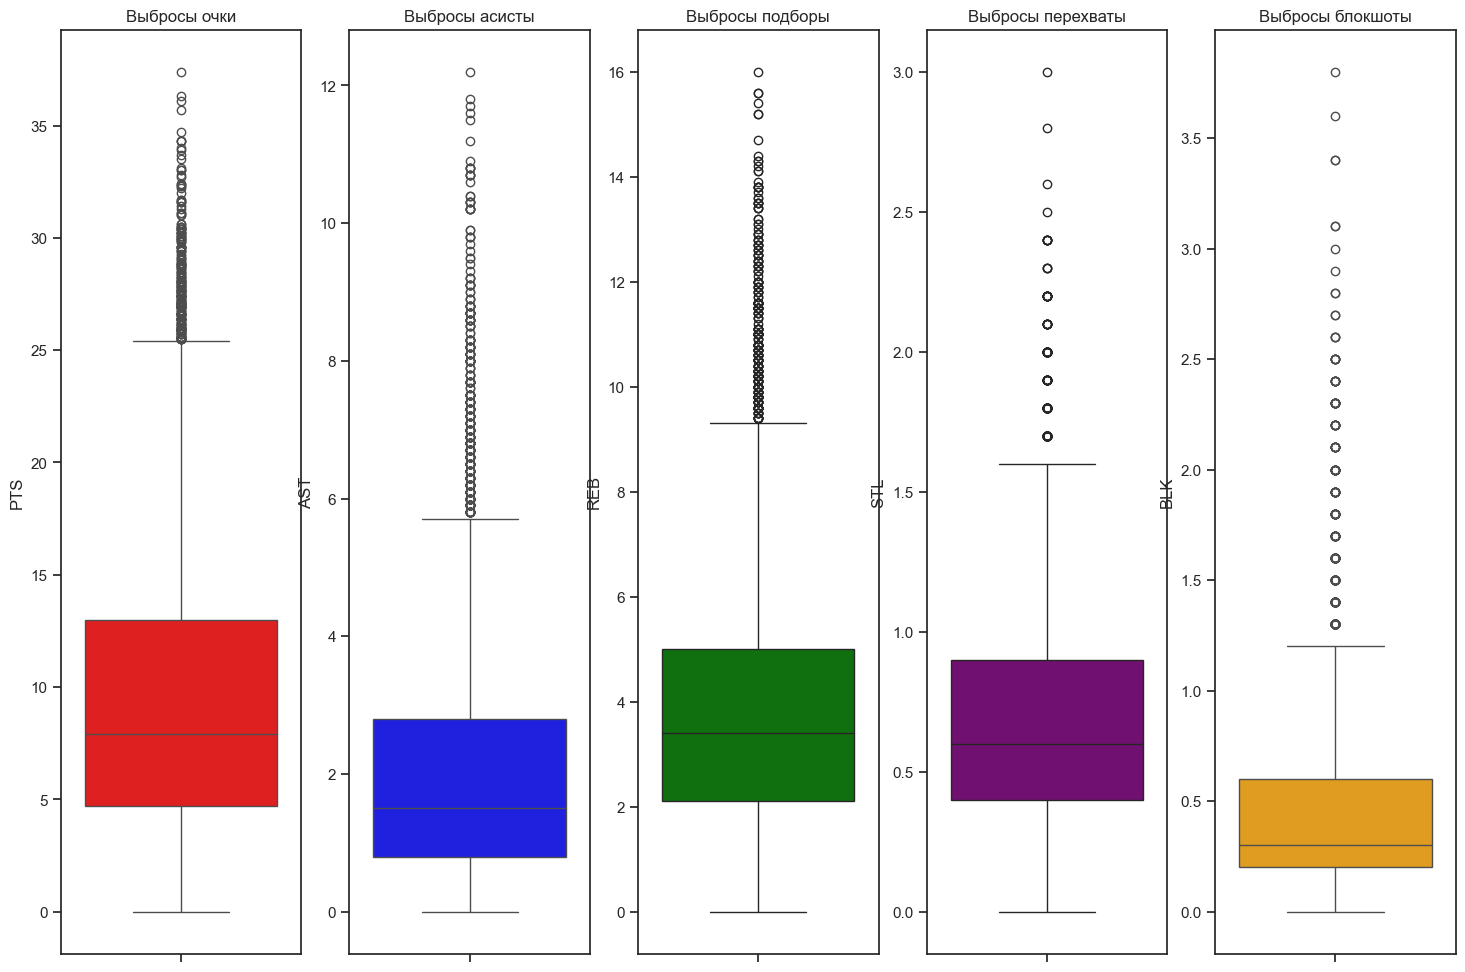

In [340]:
fig, axes = plt.subplots(1, 5, figsize=(18, 12))

sns.boxplot(data=df_players_clean['PTS'], ax=axes[0], color="red")
axes[0].set_title('Выбросы очки')

sns.boxplot(data=df_players_clean['AST'], ax=axes[1], color="blue")
axes[1].set_title('Выбросы асисты')

sns.boxplot(data=df_players_clean['REB'], ax=axes[2], color="green")
axes[2].set_title('Выбросы подборы')

sns.boxplot(data=df_players_clean['STL'], ax=axes[3], color="purple")
axes[3].set_title('Выбросы перехваты')

sns.boxplot(data=df_players_clean['BLK'], ax=axes[4], color="orange")
axes[4].set_title('Выбросы блокшоты')

plt.show()

#### Корреляционная матрица

TOV(потери за матч) коррелируют с количеством очков, минут и асистами за матч, что логично(больше пользы от игрока в атаке = лучше против него защищаются)

Не такой очевидной являются корреляция между очками и асистами(это может происходить из-за сдваивания на игроке набирающем хорошие очки, следовательно появляются открытые тиммейты)

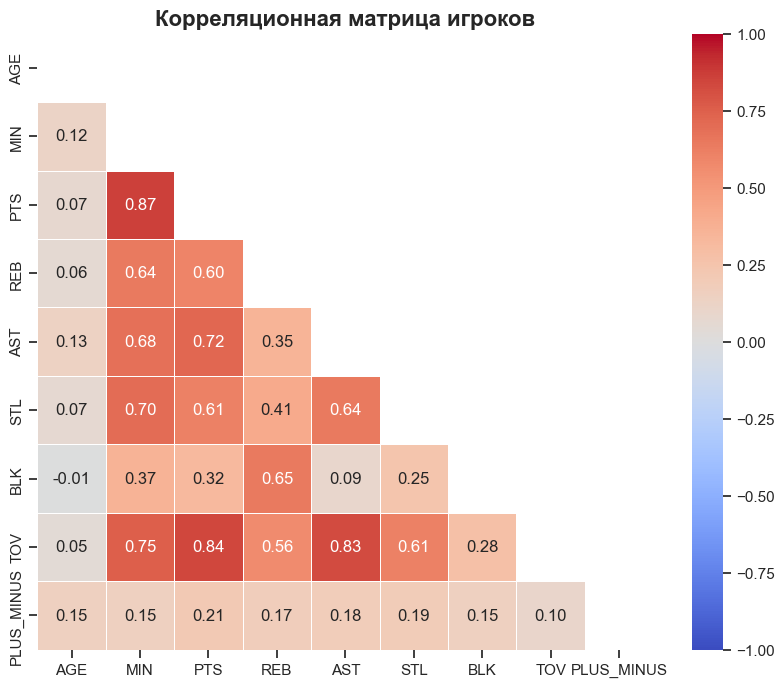

In [341]:
cols_for_corr = ['AGE', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS']
corr_matrix = df_players_clean[cols_for_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Корреляционная матрица игроков', fontsize=16, fontweight='bold')
plt.show()

#### Тру шутинг и задействование

График показывает разделение игроков на типы

1) правый верхний угол - суперзвезды, которые имеют большое задействование, и при этом они завершают атаки с высокой точностью
2) правый нижний - мусорные скороры(много на себя берут и плохо реализуют)
3) левый верхний - качественные ролевики(мало берут на себя с хорошей реализацией)

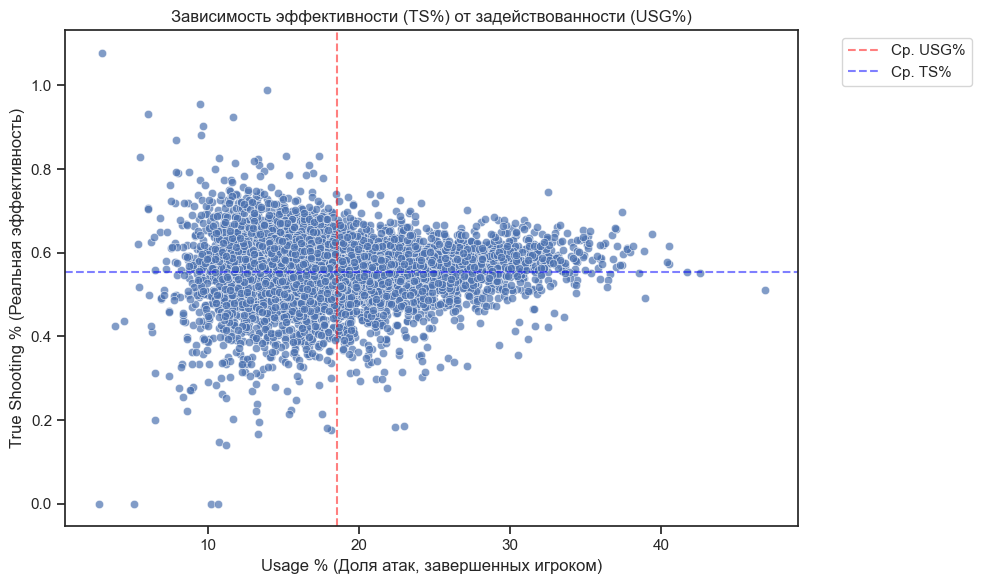

In [342]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_players_clean, x='USG_PCT', y='TS_PCT', alpha=0.7, palette='tab10')

plt.axvline(x=df_players_clean['USG_PCT'].mean(), color='red', linestyle='--', alpha=0.5, label='Ср. USG%')
plt.axhline(y=df_players_clean['TS_PCT'].mean(), color='blue', linestyle='--', alpha=0.5, label='Ср. TS%')

plt.title('Зависимость эффективности (TS%) от задействованности (USG%)')
plt.xlabel('Usage % (Доля атак, завершенных игроком)')
plt.ylabel('True Shooting % (Реальная эффективность)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Процент реализации к попыткам с учетом плюс-минуса

Данная графика показывает, что даже при хорошей реализации на больших попытках игрок может вредить команде(с ним на площадке команда больше пропускает, чем забивает)

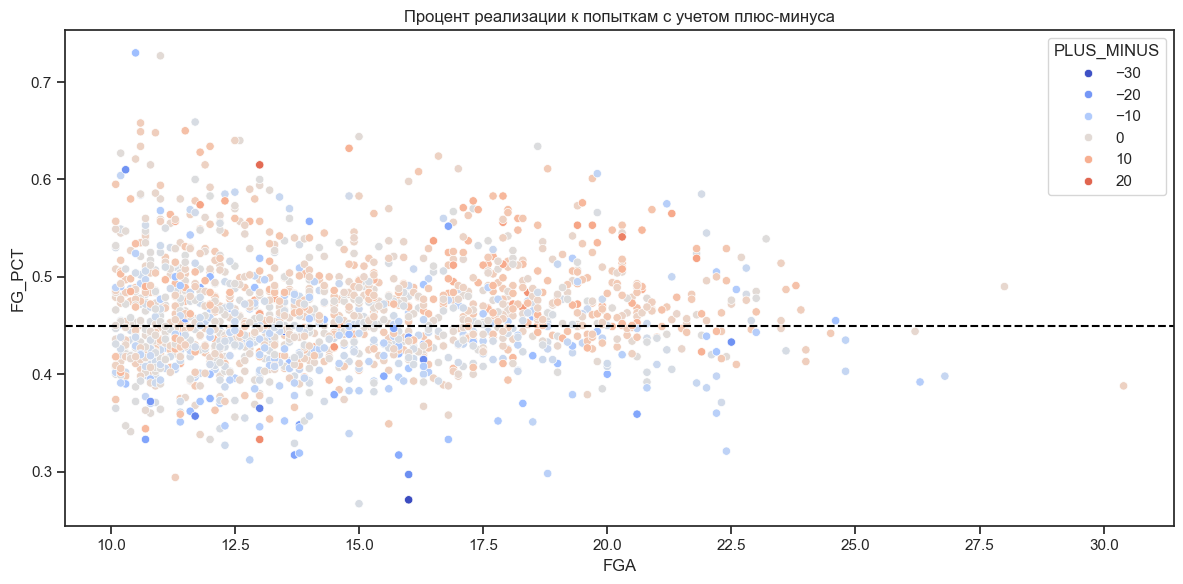

In [344]:
sns.scatterplot(data=df_players[df_players['FGA'] > 10], x='FGA', y='FG_PCT', hue='PLUS_MINUS', palette='coolwarm')
plt.axhline(0.45, color='black', linestyle='--')
plt.title('Процент реализации к попыткам с учетом плюс-минуса')
plt.tight_layout()
plt.show()

## Подготовка данных по командам

#### Распределение данных


Распределение данных показывает, что в среднем процент побед - 50%

Но процент побед смещен от центра, так как есть контендеры(команды которые борятся за титул) и такнкующие команды(они сливают сезон ради хорошего пика на драфте)


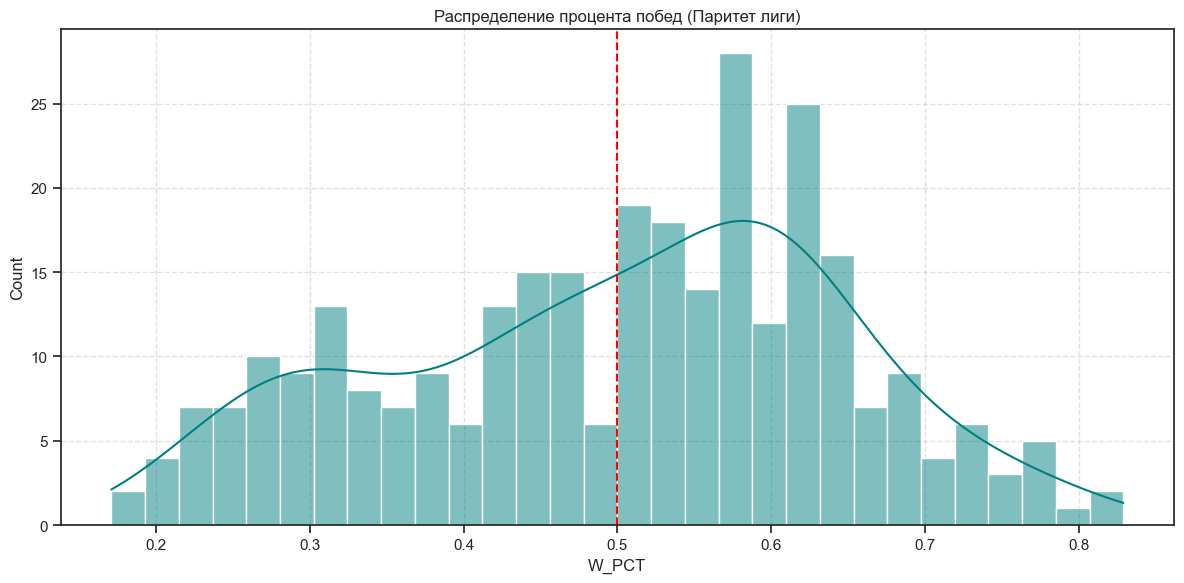

In [345]:
sns.histplot(df_teams_reg['W_PCT'], bins=30, kde=True, color='teal')
plt.axvline(0.5, color='red', linestyle='--')
plt.title('Распределение процента побед (Паритет лиги)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Результативность по годам

Мы видим, что с каждым годом кол-во очков команд в среднем за матч смещается в верх, а количество попыток в право

Это говорит о том, что темп в лиге увеличивается(время, которое команда тратит на атаку уменьшается)


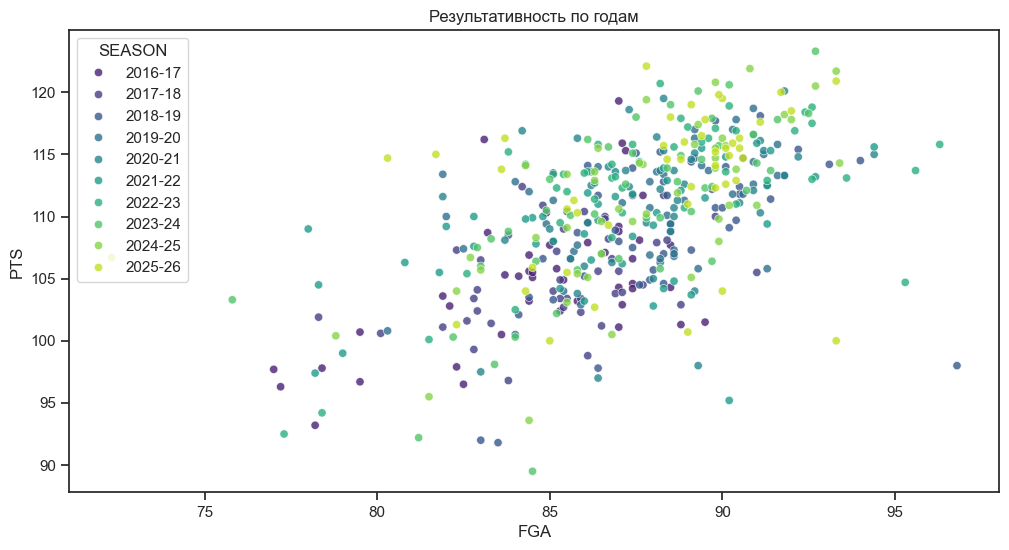

In [346]:
sns.scatterplot(data=df_teams, x='FGA', y='PTS', hue='SEASON', palette='viridis', alpha=0.8)
plt.title('Результативность по годам')
plt.show()

#### Значимость скоринга франчайза в регулярке и плей-офф


Как можно заметить влияние количества забитых очков главной звездой уменьшается в плей-офф


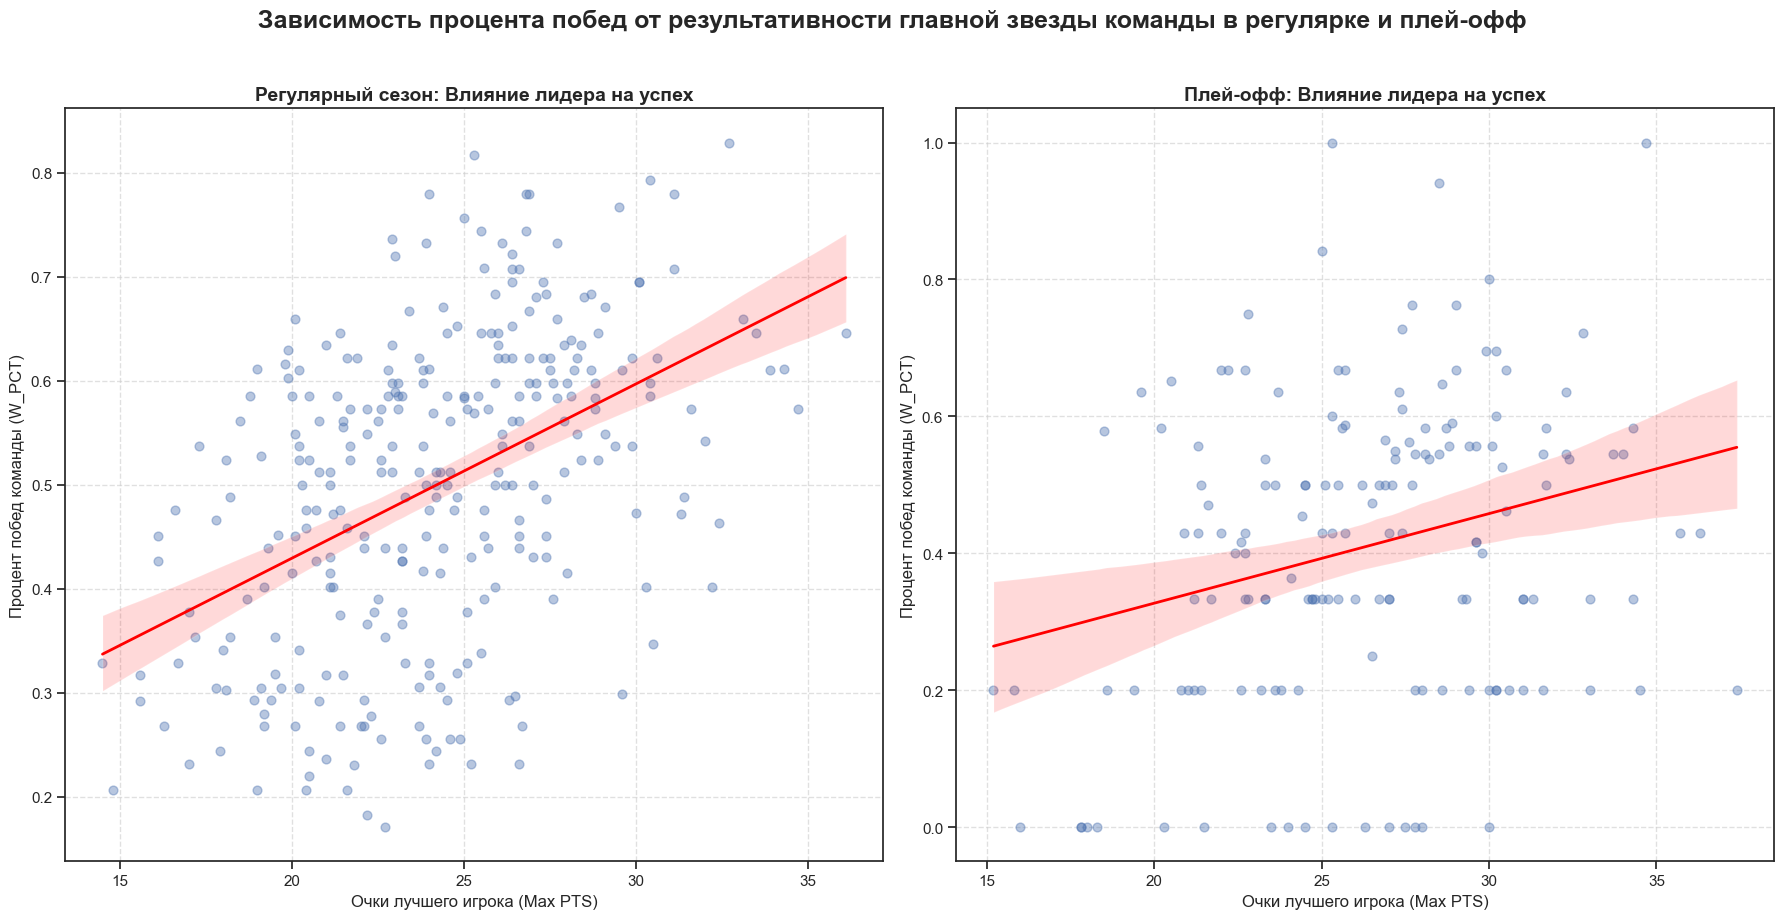

In [347]:
top_scorers_reg = df_players_reg.groupby(['TEAM_ID', 'SEASON'])['PTS'].max().reset_index()
merged_reg = pd.merge(top_scorers_reg, df_teams_reg[['TEAM_ID', 'SEASON', 'W_PCT', 'TEAM_NAME']], on=['TEAM_ID', 'SEASON'])

top_scorers_po = df_players_po.groupby(['TEAM_ID', 'SEASON'])['PTS'].max().reset_index()
merged_po = pd.merge(top_scorers_po, df_teams_po[['TEAM_ID', 'SEASON', 'W_PCT', 'TEAM_NAME']], on=['TEAM_ID', 'SEASON'])

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.regplot(data=merged_reg, x='PTS', y='W_PCT', scatter_kws={'alpha':0.4, 's':40}, line_kws={'color':'red', 'lw':2}, ax=axes[0])
axes[0].set_title('Регулярный сезон: Влияние лидера на успех', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Очки лучшего игрока (Max PTS)', fontsize=12)
axes[0].set_ylabel('Процент побед команды (W_PCT)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.regplot(data=merged_po, x='PTS', y='W_PCT', scatter_kws={'alpha':0.4, 's':40}, line_kws={'color':'red', 'lw':2}, ax=axes[1])
axes[1].set_title('Плей-офф: Влияние лидера на успех', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Очки лучшего игрока (Max PTS)', fontsize=12)
axes[1].set_ylabel('Процент побед команды (W_PCT)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Зависимость процента побед от результативности главной звезды команды в регулярке и плей-офф', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### Стабильность франшиз


График полностью отражает стабильность каждой из команд в лиге за последние 10 лет

Так например:

Бостон Селтикс - самые стабильные по регулярному сезону, но при этом у них всего 1 чемпионство за последние 10 лет

Голден Стейт - команда поставившая рекорд по количеству побед в регулярном чемпионате за 1 сезон, а также многократный чемпион нба(больше всех чемпионст за этот отрезок - 3), но при этом они находятся в середине

Также можно сказать, что ни одна команда из правой части не становилась чемпионом за последние 10 лет


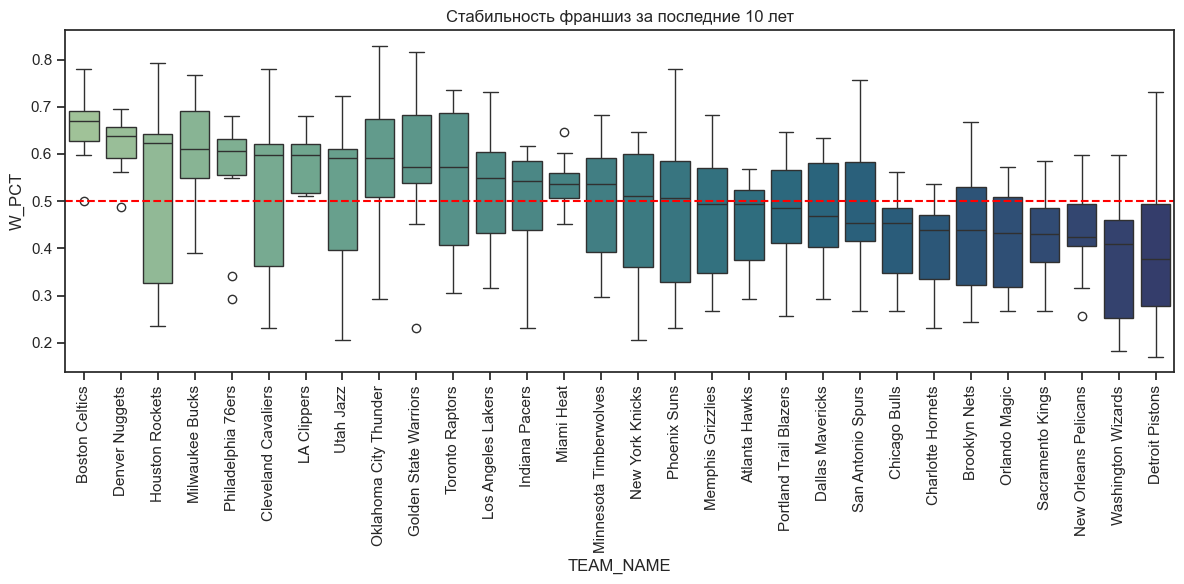

In [348]:
order = df_teams_reg.groupby('TEAM_NAME')['W_PCT'].median().sort_values(ascending=False).index
sns.boxplot(data=df_teams_reg, x='TEAM_NAME', y='W_PCT', order=order, palette='crest')
plt.tick_params(axis='x', rotation=90)
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Стабильность франшиз за последние 10 лет')
plt.tight_layout()
plt.show()

#### Баскебольная революция


График показывает революцию, направленую на рост количества 3-очковых бросков в баскеболе

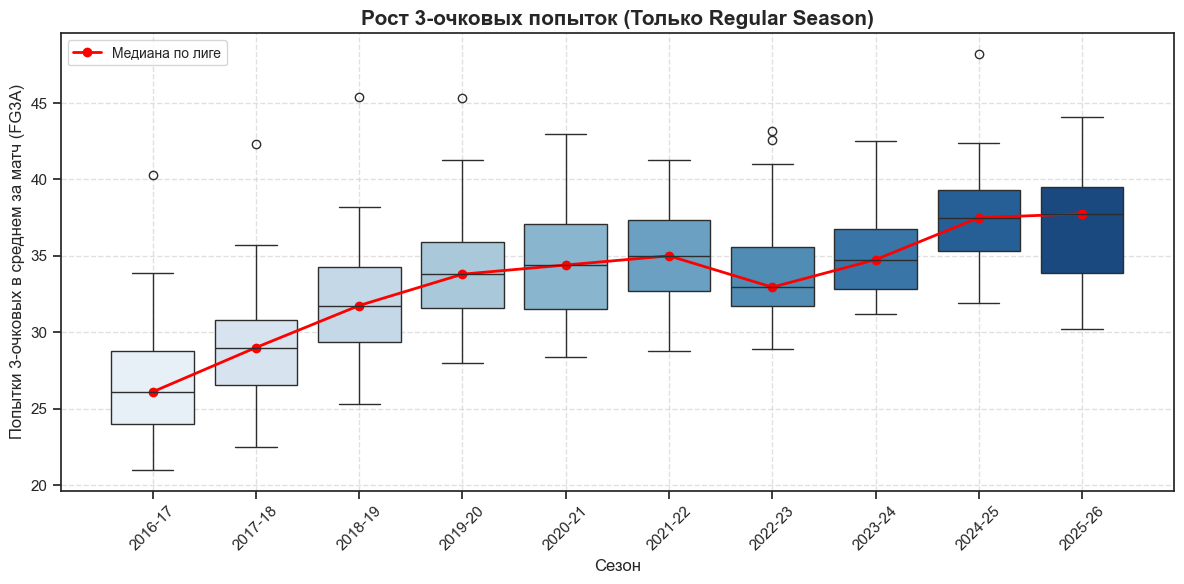

In [349]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_teams_reg, x='SEASON', y='FG3A', palette='Blues')

plt.title('Рост 3-очковых попыток (Только Regular Season)', fontsize=15, fontweight='bold')
plt.xlabel('Сезон', fontsize=12)
plt.ylabel('Попытки 3-очковых в среднем за матч (FG3A)', fontsize=12)
plt.xticks(rotation=45)

medians = df_regular.groupby('SEASON')['FG3A'].median().values

plt.plot(range(len(medians)), medians, color='red', marker='o', linestyle='-', linewidth=2, label='Медиана по лиге')

plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Основные задачи

1)Предсказать победителя NBA

2)Предсказание по 4 индивидуальным наградам: MVP, MIP, DPOY, ROY